# 4a. Default Prediction: Logistic Regression with Feature Selection 

#### Outline of this notebook:  
* **Section 1:** Objective
* **Section 2:** Load Cleaned Dataset
* **Section 3:** Feature Preprocessing
  * 3.1: Define feature types
  * 3.2: Train-test split (time-based)
  * 3.3: Build Preprocessing Pipeline
* **Section 4:** Logistic Regression – Feature Set Comparison  
  * 4.1: Full Feature Set  
  * 4.2: Intuition-Based Feature Set  
  * 4.3: Filter-Based Feature Selection  
  * 4.4: LASSO-Based Feature Selection  
  * 4.5: Permutation-Based Feature Selection
* **Section 5:** Model Comparisons
  * 5.1: Threshold Selection Using Precision–Recall Trade-off
  * 5.2: Discriminatory Power (AUC / Gini)
  * 5.3: Calibration + Classification Metrics
  * 5.4: Interpretation
* **Section 6:** Feature Importance
  * 6.1: Coefficient table (signed coefficient, SE, p-value, VIF)
  * 6.2: Permutation importance on test set
* **Section 7:** Discussions

---
## Section 1: Objective

The goal of this notebook is to build a **logistic regression model to predict loan default** and evaluate how different **feature selection strategies** affect model performance.

Logistic regression is one of the **most widely used** methods for credit risk modeling, especially for predicting loan default, because it provides probabilistic outputs and is easy to interpret. In practice, it remains a standard approach in banks and financial institutions, particularly for regulatory and production models such as credit scoring. Its transparency, stability, and ease of validation make it well-suited for meeting regulatory requirements.

We compare multiple approaches: from using all features to more targeted selections based on intuition and data-driven methods (e.g., LASSO, permutation importance). The goal is to understand:

- Which features are most useful for predicting default  
- How model performance changes with different feature sets  
- Whether simpler, well-chosen features can perform as well as or better than the full set  

This helps identify a useful model for credit risk prediction.

---
## Section 2: Load Cleaned Dataset 

In [4]:
import pandas as pd 
import sys
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import f_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, log_loss,
    brier_score_loss, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_selection import SelectKBest, f_classif

In [5]:
df_cleaned = pd.read_parquet("../data/processed/LendingClub_features.parquet")

In [6]:
df_cleaned.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,income_to_loan_ratio,payment_to_income,inq_per_credit_year,dti_x_int_rate,loan_to_installment,delinq_rate,fico_band,dti_band,unemployment_rate,fed_funds_rate
0,5000.0,36.0,0.1065,162.87,B,B2,10.0,RENT,24000.0,Verified,...,4.800000,0.069444,0.024094,2.944725,30.699331,0.0,670_739,high,8.5,0.07
1,2500.0,60.0,0.1527,59.83,C,C4,0.5,RENT,30000.0,Source Verified,...,12.000000,0.016667,0.183491,0.152700,41.785057,0.0,670_739,very_low,8.5,0.07
2,2400.0,36.0,0.1596,84.33,C,C5,10.0,RENT,12252.0,Not Verified,...,5.105000,0.065295,0.081102,1.391712,28.459623,0.0,670_739,very_low,8.5,0.07
3,10000.0,36.0,0.1349,339.31,C,C1,10.0,RENT,49200.0,Source Verified,...,4.920000,0.067751,0.032880,2.698000,29.471575,0.0,670_739,medium,8.5,0.07
4,3000.0,60.0,0.1269,67.79,B,B5,1.0,RENT,80000.0,Source Verified,...,26.666667,0.007500,0.000000,2.276586,44.254314,0.0,670_739,medium,8.5,0.07


#### Limit to pre-COVID loans

To ensure a stable and consistent economic environment, I exclude observations from the COVID-19 period and restrict the analysis to loans issued up to 2019. This avoids potential distortions driven by the unprecedented shocks during the pandemic.

In [8]:
df_cleaned['issue_d'].agg(['min', 'max'])

min   2007-06-01
max   2020-09-01
Name: issue_d, dtype: datetime64[ns]

In [9]:
print(f"Number of observations before restricting to 2019-12-01: {df_cleaned.shape[0]:,}")

Number of observations before restricting to 2019-12-01: 1,860,765


In [10]:
df_cleaned = df_cleaned[df_cleaned['issue_d'] <= '2019-12-01']

In [11]:
print(f"Number of observations after restricting to 2019-12-01: {df_cleaned.shape[0]:,}")

Number of observations after restricting to 2019-12-01: 1,856,478


---
## Section 3: Feature Preprocessing

In this section, I prepare the features for modeling by combining direct data cleaning with a reusable preprocessing pipeline.

The main steps are as follows:

- **3.1: Define feature types**: Separate variables into numerical and categorical features.

- **3.2: Train-test split**

- **3.3: Build preprocessing pipeline**:
  - **Categorical variables**: Impute missing values using the most frequent value and apply one-hot encoding, converting each category into binary (0/1) indicator variables.
  - **Numerical variables**: Impute missing values using the median and apply feature scaling (standardization) for linear models (e.g. logistic regression, LASSO) that are sensitive to scale. 
  - These steps are implemented using `ColumnTransformer` and `Pipeline` from `sklearn`, and are applied during model training rather than directly modifying `df_cleaned`. This ensures consistency, reproducibility, and prevents data leakage.

### 🔷 3.1: Define feature types

In [14]:
# 1. Target variable
target = 'default'

# 2. Variables to drop (before modeling)
drop_cols = ['grade', 'sub_grade', 'int_rate', 'zip_code', 'addr_state',
             'dti', 'fico_range_low']
    # grade, sub_grade, int_rate:
    #  - assigned by LendingClub's internal risk model at origination
    #  - using them would be circular: they are outputs of a prior credit
    #    assessment, not independent borrower characteristics
    #  - including them would inflate model performance without adding
    #    genuine predictive signal from borrower fundamentals
    # addr_state, zip_code:
    #  - dropped to avoid potential proxy effects for protected characteristics
    #    and mitigate fairness / regulatory concerns in credit risk modeling
    # dti, fico_range_low
    #  - dropped as their bands are included instead

# 3. Time-related (handle separately)
date_cols = ['issue_d']

# 4. Categorical features
categorical_cols = [
    #'sub_grade', 
    'home_ownership', 'verification_status',
    'purpose',
    'initial_list_status', 'application_type',
    'fico_band', 'dti_band'
]

# 5. Numeric features (all the others)
numeric_cols = [
    col for col in df_cleaned.columns
    if col not in categorical_cols + date_cols + drop_cols + [target]
]

# 6. Final check
print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))
print("Date:", date_cols)

Numeric: 74
Categorical: 7
Date: ['issue_d']


In [15]:
#list(df_cleaned[numeric_cols].dtypes) ## Checking dtype of numeric features 

### 🔷 3.2: Train-validation-test split (time-based)

We use a **time-based** train–validation–test split to mimic the real-world setting where the model is trained on past loans, tuned on a more recent validation period, and evaluated on future loans. 

This ensures the model only uses past data to predict future outcomes, just like in real-world lending. It also gives a more reliable evaluation of both model tuning and how the model will perform on truly new loans.

In [17]:
# Start from original data
X = df_cleaned.copy()

# Drop unnecessary columns
X = X.drop(columns=[col for col in drop_cols if col in X.columns])

# Target
y = df_cleaned[target]

# Combine
df_model = X.copy()
df_model[target] = y

# Sort by issue date
df_model = df_model.sort_values("issue_d")

# Split indices
n = len(df_model)
train_end = int(n * 0.6)
val_end   = int(n * 0.8)

# Split data (time-based)
X_train = df_model.iloc[:train_end].drop(columns=[target])
y_train = df_model.iloc[:train_end][target]

X_val = df_model.iloc[train_end:val_end].drop(columns=[target])
y_val = df_model.iloc[train_end:val_end][target]

X_test = df_model.iloc[val_end:].drop(columns=[target])
y_test = df_model.iloc[val_end:][target]

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (1113886, 82)
Validation size: (371296, 82)
Test size: (371296, 82)


In [18]:
# Check date ranges
print(f"Train date range: {X_train['issue_d'].min().date()} → {X_train['issue_d'].max().date()}")
print(f"Validation date range: {X_val['issue_d'].min().date()} → {X_val['issue_d'].max().date()}")
print(f"Test date range: {X_test['issue_d'].min().date()} → {X_test['issue_d'].max().date()}")

Train date range: 2007-06-01 → 2016-07-01
Validation date range: 2016-07-01 → 2017-08-01
Test date range: 2017-08-01 → 2019-12-01


In [19]:
# [Important] Drop time variable (not used for prediction)
X_train = X_train.drop(columns=["issue_d"])
X_val = X_val.drop(columns=["issue_d"])
X_test  = X_test.drop(columns=["issue_d"])

### 🔷 3.3: Build Preprocessing Pipeline

To ensure consistent and reproducible feature transformations, I construct a preprocessing pipeline using `ColumnTransformer` and `Pipeline` from `sklearn`.

- **Categorical variables**:
  - Missing values are imputed using the most frequent value.
  - Variables are then one-hot encoded, where each category is converted into a binary (0/1) indicator variable.

- **Numerical variables**:
  - Missing values are imputed using the median.
  - Features are standardized (mean 0, unit variance) for models that are sensitive to scale, such as Logistic Regression and LASSO.

These transformations are applied within the modeling pipeline during training, rather than directly modifying the dataset. This approach ensures that the same preprocessing steps are consistently applied to both training and test data, and helps prevent data leakage.

In [21]:
# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# Numerical pipeline (with scaling for logit/LASSO)
num_pipeline_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Combined preprocessor => Will be defined for each feature set using 'build_preprocessor' function below.

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


---
## Section 4:  Logistic Regression – Feature Set Comparison  

In this section, we estimate logistic regression models using different feature sets to examine how feature selection affects predictive performance.

We begin with a **full set** of available features as a benchmark. 
We then compare this to several alternative approaches: 
* an **intuition-based** subset guided by domain knowledge
* a **filter-based** method using univariate statistical tests
* a **LASSO-based** approach that performs embedded feature selection through regularization
* a **permutation-based** method that selects features based on their impact on model performance

This setup allows us to study the trade-offs between model simplicity, interpretability, and predictive power. Model performance across these specifications is evaluated and compared in Section 5.

### 🔷 4.0: Helper functions

In [24]:
## Helper: build preprocessor for a given feature set

def build_preprocessor(feature_set):
    num_cols = [col for col in numeric_cols if col in feature_set]
    cat_cols = [col for col in categorical_cols if col in feature_set]
    
    return ColumnTransformer([
        ("num", num_pipeline_scaled, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ])

In [25]:
def tune_logit_model(feature_set, X_train, y_train, X_val, y_val):
    """
    Step 1: Find best hyperparameters using validation AUC.
    Step 2: Refit final model on train + val combined with best params.
    Returns the refitted model, best params, and best validation AUC.
    """
    C_grid = [0.01, 0.1, 1, 10]
    penalty_grid = ["l2"]

    best_auc = -1
    best_params = None

    X_train_sub = X_train[feature_set]
    X_val_sub   = X_val[feature_set]

    # --- Step 1: tune on train/val ---
    for C in C_grid:
        for penalty in penalty_grid:
            try:
                preprocessor = build_preprocessor(feature_set)
                pipeline = Pipeline([
                    ("preprocess", preprocessor),
                    ("model", LogisticRegression(
                        C=C,
                        penalty=penalty,
                        solver="lbfgs",
                        max_iter=1000,
                        random_state=42
                    ))
                ])
                pipeline.fit(X_train_sub, y_train)
                y_val_pred = pipeline.predict_proba(X_val_sub)[:, 1]
                auc = roc_auc_score(y_val, y_val_pred)

                if auc > best_auc:
                    best_auc = auc
                    best_params = {"C": C, "penalty": penalty}

            except:
                continue

    # --- Step 2: refit on train + val with best params ---
    X_trainval = pd.concat([X_train_sub, X_val_sub])
    y_trainval = pd.concat([y_train, y_val])

    final_preprocessor = build_preprocessor(feature_set)
    best_model = Pipeline([
        ("preprocess", final_preprocessor),
        ("model", LogisticRegression(
            C=best_params["C"],
            penalty=best_params["penalty"],
            solver="lbfgs",
            max_iter=1000,
            random_state=42
        ))
    ])
    best_model.fit(X_trainval, y_trainval)

    return best_model, best_params, best_auc

### 🔷 4.1: Full feature set

In [27]:
features_full = X_train.columns.tolist()

start = time.time()
## Train model with hyperparameter tuning
logit_full, params_full, val_auc_full = tune_logit_model(
    features_full,
    X_train, y_train,
    X_val, y_val
)

print("Run time:", time.strftime("%H:%M:%S", time.gmtime(time.time() - start)))
print("Best params:", params_full)
print("Validation AUC:", val_auc_full)

Run time: 00:02:12
Best params: {'C': 0.01, 'penalty': 'l2'}
Validation AUC: 0.712429254498485


### 🔷 4.2: Intuition-based feature set

In this specification, we construct a feature set based on economic intuition and domain knowledge of credit risk. The selected variables capture key dimensions associated with a borrower's likelihood of default:

- **Loan characteristics:**  
  `loan_amnt`, `term`, and `int_rate` reflect loan terms and pricing.

- **Borrower capacity (ability to pay):**  
  `annual_inc`, `emp_length`, and `dti` capture income and repayment burden.

- **Credit history and behavior:**  
  `fico_range_low`, `inq_last_6mths`, `open_acc`, `pub_rec`, `total_acc`, and `credit_age` summarize creditworthiness, past usage, and length of credit history.

- **Credit utilization:**  
  `revol_bal` and `revol_util` measure current credit usage.

- **Borrower characteristics:**  
  `home_ownership`, `verification_status`, and `purpose` capture additional heterogeneity.

- **Engineered features (economically motivated):**  
 `dti_x_int_rate` (repayment pressure × borrowing cost), `payment_to_income` (monthly burden relative to income), `inq_per_credit_year` (inquiry intensity), and `delinq_rate` (delinquency frequency normalized by credit history length).

- **Macroeconomic conditions at origination:**  
  `unemployment_rate` and `fed_funds_rate` capture the broader economic environment at loan origination.

This parsimonious and interpretable feature set serves as a benchmark against more data-driven approaches.

In [29]:
features_intuition = [
    # Loan characteristics
    "loan_amnt", "term", "int_rate",
    # Borrower capacity
    "annual_inc", "emp_length", "dti_band",
    # Credit history
    "fico_band", "inq_last_6mths", "open_acc", "pub_rec", "total_acc", "credit_age",
    # Credit utilization
    "revol_bal", "revol_util",
    # Borrower characteristics
    "home_ownership", "verification_status", "purpose", "application_type",
    # Engineered features (economically motivated)
    "dti_x_int_rate",
    "payment_to_income",
    "inq_per_credit_year",
    "delinq_rate",
    # Macroeconomic conditions at origination
    "unemployment_rate", "fed_funds_rate"
]

features_intuition = [col for col in features_intuition if col in X_train.columns]

start = time.time()
# Train model with hyperparameter tuning
logit_intuition, params_intuition, val_auc_intuition = tune_logit_model(
    features_intuition,
    X_train, y_train,
    X_val, y_val
)

print("Run time:", time.strftime("%H:%M:%S", time.gmtime(time.time() - start)))
print("Best params:", params_intuition)
print("Validation AUC:", val_auc_intuition)

Run time: 00:00:45
Best params: {'C': 0.01, 'penalty': 'l2'}
Validation AUC: 0.7002680248134717


### 🔷 4.3: Filter-based feature selection

In this approach, we select features based on how strongly each variable is related to the target. Specifically, we use statistical tests (ANOVA F-tests) to identify variables that are **most predictive of default.**

We apply separate procedures for numeric and categorical features.
* For **numeric features**, we first impute missing values using the median, then select the top 20 features with the highest F-statistics.
* For **categorical features**, we first impute missing values using the most frequent category, then apply one-hot encoding to convert each variable into multiple dummy variables. Feature selection is performed on these encoded features. Since selection occurs at the dummy level, we map the selected dummies back to their original variables and retain the entire categorical variable if any of its categories are selected.

The final feature set combines the top numeric and categorical variables. This method provides a simple and computationally efficient way to reduce dimensionality. 

However, a caveat of this method is that it evaluates each feature independently and does not account for interactions between variables.

In [31]:
## --- (A) For numeric features 
numeric_available = [col for col in numeric_cols if col in X_train.columns]

# 1. Impute first (otherwise, SelectKBest wouldn't work)
imputer = SimpleImputer(strategy="median")
X_num_imputed = imputer.fit_transform(X_train[numeric_available])

# 2. Then select features
selector = SelectKBest(score_func=f_classif, k=20)
selector.fit(X_num_imputed, y_train)

top_numeric_filter = np.array(numeric_available)[selector.get_support()].tolist()

In [32]:
## --- (B) For categorical features 
categorical_available = [col for col in categorical_cols if col in X_train.columns]

# 1. Impute missing values 
imputer_cat = SimpleImputer(strategy="most_frequent")
X_cat_imputed = imputer_cat.fit_transform(X_train[categorical_available])

# 2. Encode (converts each categorical variable into mutiple dummy variables) 
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat_encoded = encoder.fit_transform(X_cat_imputed)

# 3. Select top categorical features 
selector_cat = SelectKBest(score_func=f_classif, k=25)
selector_cat.fit(X_cat_encoded, y_train)

# 4. Get names of encoded features 
encoded_feature_names = encoder.get_feature_names_out(categorical_available)
selected_encoded = encoded_feature_names[selector_cat.get_support()]
print("Selected categorical encoded variables are: ")
print(selected_encoded)

# 5. Map back from encoded variables to original categorical variables 
top_categorical_filter = list(set([
    col for name in selected_encoded
    for col in categorical_available
    if name.startswith(f"{col}_")
]))
    ## => Importantly, 
    ##    if ANY dummy from a categorical variable is selected, 
    ##    then we keep the WHOLE variable. 
    ##    e.g. only if addr_state_NY and addr_state_CA show up as top features, 
    ##         we keep the whole add_state, not just NY and CA. 

Selected categorical encoded variables are: 
['home_ownership_MORTGAGE' 'home_ownership_RENT'
 'verification_status_Not Verified' 'verification_status_Source Verified'
 'verification_status_Verified' 'purpose_car' 'purpose_credit_card'
 'purpose_debt_consolidation' 'purpose_home_improvement' 'purpose_house'
 'purpose_major_purchase' 'purpose_moving' 'purpose_other'
 'purpose_small_business' 'purpose_wedding' 'application_type_Individual'
 'application_type_Joint App' 'fico_band_625_669' 'fico_band_670_739'
 'fico_band_740_799' 'fico_band_800_plus' 'dti_band_high' 'dti_band_low'
 'dti_band_very_high' 'dti_band_very_low']


In [33]:
features_filter = top_numeric_filter + top_categorical_filter

print("Filter-selected features:")
print(features_filter)

Filter-selected features:
['term', 'inq_last_6mths', 'tot_cur_bal', 'open_rv_24m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'num_actv_rev_tl', 'num_rev_tl_bal_gt_0', 'num_tl_op_past_12m', 'percent_bc_gt_75', 'tot_hi_cred_lim', 'total_bc_limit', 'income_to_loan_ratio', 'inq_per_credit_year', 'dti_x_int_rate', 'loan_to_installment', 'fico_band', 'verification_status', 'home_ownership', 'dti_band', 'purpose', 'application_type']


### 📌 Filter-Selected Features Summary

The filter method selects features that capture **loan characteristics, borrower financial condition, and credit behavior**.

- **Loan terms & pricing:** `loan_amnt`, `term`, `int_rate`, `sub_grade`  
- **Borrower financial condition:** `dti`, `home_ownership`, `verification_status`  
- **Credit score & risk signals:** `fico_range_low`, `inq_last_6mths`  
- **Credit utilization & limits:** `tot_cur_bal`, `avg_cur_bal`, `bc_open_to_buy`, `percent_bc_gt_75`, `tot_hi_cred_lim`, `total_bc_limit`  
- **Recent credit activity:** `acc_open_past_24mths`, `num_tl_op_past_12m`, `mo_sin_rcnt_rev_tl_op`, `mo_sin_rcnt_tl`, `mths_since_recent_bc`  
- **Account composition:** `mort_acc`, `num_actv_rev_tl`, `num_rev_tl_bal_gt_0`  

Overall, these features emphasize **creditworthiness, recent borrowing behavior, and available credit capacity**, which are key drivers of default risk.

In [35]:
# Train model with hyperparameter tuning
logit_filter, params_filter, val_auc_filter = tune_logit_model(
    features_filter,
    X_train, y_train,
    X_val, y_val
)

print("Best params:", params_filter)
print("Validation AUC:", val_auc_filter)

Best params: {'C': 0.01, 'penalty': 'l2'}
Validation AUC: 0.7057910496575964


### 🔷 4.4: LASSO-based feature selection

In this approach, we use **L1-regularized logistic regression (LASSO)** to perform feature selection within the modeling framework. Unlike the filter method (Section 4.3), LASSO evaluates features jointly and shrinks less important coefficients toward zero, effectively removing them from the model.

The procedure is as follows:
* First, we build a pipeline that combines preprocessing (imputation, scaling, and encoding) with a logistic regression model using an L1 penalty.
* Next, we fit the model on the training data.
* We then extract the coefficients for each transformed feature, retaining those with non-zero values and discarding the rest.
* Finally, we re-estimate a standard logistic regression model using the LASSO-selected features.

**Note on categorical variables:** Since LASSO operates on transformed features (including one-hot encoded variables), we map the selected features back to the original variables. For categorical variables, if any encoded category is selected, we retain the entire variable to remain consistent with the preprocessing step.

The resulting feature set reflects variables that are most relevant for prediction in a multivariate setting, accounting for correlations across features. However, the selected features may still depend on the choice of regularization strength and do not automatically capture interaction effects unless explicitly included in the model.

In [37]:
## 1. Build pipeline (pre-processing + LASSO) 
lasso_feature_pipeline = Pipeline([
    ("preprocess", build_preprocessor(features_full)),
    ("model", LogisticRegression(
        penalty="l1",
        solver="saga",       # faster than liblinear on large data
        C=0.1,
        max_iter=1000,
        tol=1e-3,            # looser tolerance is fine for feature selection
        random_state=42
    ))
])

## 2. Fit on a subsample — feature selection is stable at 200k rows
##    and avoids running LASSO on the full 1.1M training set
X_lasso = X_train[features_full].sample(n=200_000, random_state=42)
y_lasso = y_train.loc[X_lasso.index]

lasso_feature_pipeline.fit(X_lasso, y_lasso)

## 3. Get transformed feature names 
feature_names_lasso = lasso_feature_pipeline.named_steps["preprocess"].get_feature_names_out()

## 4. Get coefficients 
coef_lasso = lasso_feature_pipeline.named_steps["model"].coef_[0]

## 5. Select non-zero features (drop all features with coefficient = 0) 
selected_transformed_lasso = feature_names_lasso[coef_lasso != 0]

## 6. Map transformed feature names back to original raw feature names
selected_raw_lasso = set()
for feat in selected_transformed_lasso:
    if feat.startswith("num__"):
        selected_raw_lasso.add(feat.replace("num__", ""))
    elif feat.startswith("cat__"):
        for col in categorical_cols:
            if feat.startswith(f"cat__{col}_"):
                selected_raw_lasso.add(col)

## 7. Final LASSO-selected raw features 
features_lasso = [col for col in features_full if col in selected_raw_lasso]

print(f"LASSO selected {len(features_lasso)} raw features:")
print(features_lasso)

dropped_lasso = [col for col in features_full if col not in selected_raw_lasso]
print(f"LASSO dropped {len(dropped_lasso)} raw features:")
print(dropped_lasso)

LASSO selected 79 raw features:
['loan_amnt', 'term', 'installment', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'acc_now_delinq', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',

In [38]:
# Train model with hyperparameter tuning
logit_lasso_features, params_lasso, val_auc_lasso = tune_logit_model(
    features_lasso,
    X_train, y_train,
    X_val, y_val
)

print("Best params:", params_lasso)
print("Validation AUC:", val_auc_lasso)

Best params: {'C': 0.01, 'penalty': 'l2'}
Validation AUC: 0.7123806018506791


### 🔷 4.5: Permutation-based feature selection

In this approach, we select features based on their contribution to model performance. Specifically, we use permutation importance to measure how much each feature affects predictive accuracy.

The procedure is as follows:
- First, we take the trained full-feature logistic regression model and evaluate it on the **validation set**.
- For each feature, we randomly shuffle its values and measure how much the model's validation AUC decreases.
- Features that lead to a larger drop in performance are considered more important.
- We then summarize the results and select features with positive importance, with a fallback to the top 20 features if too few meet this criterion.
- Finally, we estimate a logistic regression model using the permutation-selected features, refitting on train+val combined.

**Important:** Permutation importance is computed on `X_val`, not `X_test`. Using the test set for feature selection would constitute data leakage — the selected feature set would reflect test set patterns, giving the permutation model an unfair advantage in test evaluation. The validation set is the correct split for all model development decisions, with the test set held out strictly for final evaluation.

In [40]:
## 1. Measure feature importance via permutation on VALIDATION set
##    (Using X_val, not X_test, to avoid leakage into test evaluation)
perm_result = permutation_importance(
    logit_full,
    X_val[features_full],
    y_val,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

## 2. Summarize importance into a table 
perm_df = pd.DataFrame({
    "feature": features_full,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

## 3. Inspect top 20 features 
display(perm_df.head(20))

## 4. Select features based on importance 
##    Keep features with positive importance, or top 20 if too few
features_perm = perm_df.loc[perm_df["importance_mean"] > 0, "feature"].tolist()

if len(features_perm) < 10:
    features_perm = perm_df.head(20)["feature"].tolist()

print(f"Permutation-selected features: {len(features_perm)}")
print(features_perm)

# Features dropped by permutation importance
dropped_perm = [col for col in features_full if col not in features_perm]

print(f"Permutation dropped features: {len(dropped_perm)}")
print(dropped_perm)

,feature,importance_mean,importance_std
1,term,0.113293,0.001138
2,installment,0.029561,0.000348
75,loan_to_installment,0.017247,0.000302
69,total_il_high_credit_limit,0.012292,0.000149
35,acc_open_past_24mths,0.011050,0.000242
68,total_bc_limit,0.009906,0.000248
70,credit_age,0.007821,0.000331
11,open_acc,0.006972,0.000096
0,loan_amnt,0.006192,0.000134
67,total_bal_ex_mort,0.006040,0.000124


Permutation-selected features: 69
['term', 'installment', 'loan_to_installment', 'total_il_high_credit_limit', 'acc_open_past_24mths', 'total_bc_limit', 'credit_age', 'open_acc', 'loan_amnt', 'total_bal_ex_mort', 'mo_sin_old_rev_tl_op', 'income_to_loan_ratio', 'num_sats', 'dti_x_int_rate', 'home_ownership', 'dti_band', 'percent_bc_gt_75', 'fico_band', 'purpose', 'num_actv_rev_tl', 'num_bc_sats', 'total_acc', 'open_rv_12m', 'avg_cur_bal', 'fed_funds_rate', 'application_type', 'bc_open_to_buy', 'open_il_24m', 'delinq_rate', 'mths_since_recent_bc', 'inq_last_6mths', 'mort_acc', 'verification_status', 'bc_util', 'num_bc_tl', 'open_act_il', 'inq_fi', 'num_rev_tl_bal_gt_0', 'delinq_2yrs', 'mths_since_recent_inq', 'unemployment_rate', 'tot_cur_bal', 'revol_bal', 'revol_util', 'num_tl_op_past_12m', 'num_tl_90g_dpd_24m', 'mths_since_last_delinq', 'total_bal_il', 'total_cu_tl', 'max_bal_bc', 'pct_tl_nvr_dlq', 'mo_sin_old_il_acct', 'inq_per_credit_year', 'num_rev_accts', 'mths_since_rcnt_il', 'op

In [41]:
# Train model with hyperparameter tuning
logit_perm, params_perm, val_auc_perm = tune_logit_model(
    features_perm,
    X_train, y_train,
    X_val, y_val
)

print("Best params:", params_perm)
print("Validation AUC:", val_auc_perm)

Best params: {'C': 0.01, 'penalty': 'l2'}
Validation AUC: 0.7127967612763073


---
## Section 5: Model Comparisons 

### 🔷 5.1: Threshold Selection Using Precision–Recall Trade-off

Before evaluating the model, it is useful to choose a **classification threshold** for default, which is deciding whether to label an observation as 0 (no default) or 1 (default) based on its predicted probability. While 0.5 is a common default choice, it is not appropriate here because default is relatively rare (about 20% of loans). Using a threshold of 0.5 would classify too many observations as no default and miss a large share of actual defaults.

Instead, we select the threshold based on **the trade-off between precision and recall.** **Precision** measures how accurate our predicted defaults are, while **recall** measures how many actual defaults we successfully identify. This trade-off is particularly useful in imbalanced settings like credit risk, where missing true defaults can be costly.

We select the threshold that **maximizes the F1 score**, which is the harmonic mean of precision and recall. This provides a principled, data-driven criterion for balancing the two objectives rather than relying on an arbitrary fixed value.

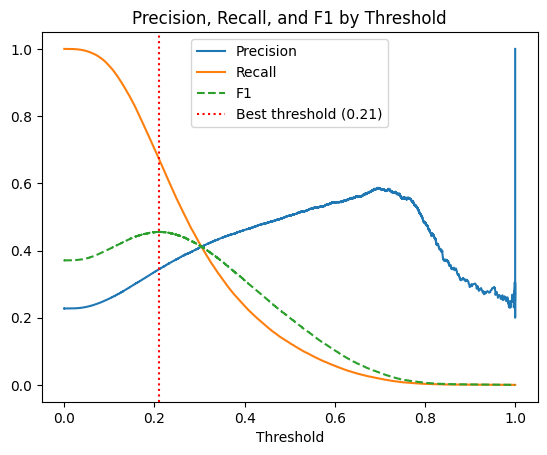

Best threshold (max F1): 0.2097
  Precision: 0.3440
  Recall:    0.6736
  F1:        0.4555


In [44]:
## Predicted probability that each obs in X_test will default
y_pred_proba_full = logit_full.predict_proba(X_test)[:, 1]

## Precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_full)

## Select threshold that maximizes F1 score
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

## Plot
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores, label="F1", linestyle="--")
plt.axvline(best_threshold, color="red", linestyle=":", label=f"Best threshold ({best_threshold:.2f})")
plt.xlabel("Threshold")
plt.title("Precision, Recall, and F1 by Threshold")
plt.legend()
plt.show()

print(f"Best threshold (max F1): {best_threshold:.4f}")
print(f"  Precision: {precision[best_idx]:.4f}")
print(f"  Recall:    {recall[best_idx]:.4f}")
print(f"  F1:        {f1_scores[best_idx]:.4f}")

In [45]:
## F1-optimal threshold from the full logistic model, applied to all models
threshold = best_threshold
print(f"Shared threshold: {threshold:.4f}")

## Save for use in notebook 4
import json
with open("../outputs/threshold.json", "w") as f:
    json.dump({"threshold": threshold}, f)

Shared threshold: 0.2097


In [46]:
# Save full model test predictions for profit analysis in notebook 5
pd.DataFrame({
    "y_true": y_test.values,
    "y_pred_proba": y_pred_proba_full
}).to_parquet("../outputs/logistic_full_test_predictions.parquet", index=False)

print("Saved test predictions to outputs/logistic_full_test_predictions.parquet")

Saved test predictions to outputs/logistic_full_test_predictions.parquet


### 🔷 5.2: Discriminatory Power (AUC / Gini)

In [48]:
from sklearn.metrics import average_precision_score

# Helper: compute KS
def compute_ks(y_true, y_pred_proba):
    data = pd.DataFrame({"y": y_true, "p": y_pred_proba}).sort_values("p", ascending=False)
    data["cum_bad"]  = (data["y"] == 1).cumsum() / (data["y"] == 1).sum()
    data["cum_good"] = (data["y"] == 0).cumsum() / (data["y"] == 0).sum()
    return np.max(np.abs(data["cum_bad"] - data["cum_good"]))


# Store models in dict
models = {
    "Full": logit_full,
    "Intuition": logit_intuition,
    "Filter": logit_filter,
    "LASSO": logit_lasso_features,
    "Permutation": logit_perm
}

results_auc = []

for name, model in models.items():
    X_test_sub   = X_test[model.feature_names_in_]
    y_pred_proba = model.predict_proba(X_test_sub)[:, 1]

    auc    = roc_auc_score(y_test, y_pred_proba)
    gini   = 2 * auc - 1
    ks     = compute_ks(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)

    results_auc.append({
        "Model":   name,
        "ROC-AUC": auc,
        "Gini":    gini,
        "KS":      ks,
        "PR-AUC":  pr_auc,
    })

df_auc = pd.DataFrame(results_auc).sort_values("ROC-AUC", ascending=False)
display(df_auc)

,Model,ROC-AUC,Gini,KS,PR-AUC
0,Full,0.699875,0.399751,0.295445,0.391637
3,LASSO,0.699831,0.399661,0.295232,0.391785
4,Permutation,0.699805,0.399610,0.294772,0.391492
2,Filter,0.694695,0.389390,0.285626,0.383958
1,Intuition,0.683364,0.366728,0.267943,0.370917


We compare model performance using **threshold-free** metrics, which measure the model's ability to rank borrowers by default risk regardless of where the classification cutoff is placed.

- **ROC-AUC:** The probability that a randomly chosen defaulter is ranked higher than a non-defaulter. Higher is better.
- **Gini:** A rescaled version of AUC (`2 × AUC − 1`).
- **KS (Kolmogorov–Smirnov):** Maximum gap between the cumulative distributions of defaulters and non-defaulters when sorted by predicted risk.
- **PR-AUC (Precision-Recall AUC):** Area under the precision-recall curve. Unlike ROC-AUC, it focuses entirely on the positive class (defaults) and is more informative under class imbalance — a model that trivially predicts non-default cannot inflate PR-AUC the way it can ROC-AUC.

The results reveal a two-tier structure. The full, LASSO, and permutation models are nearly indistinguishable — ROC-AUC spans just 0.0001 across the three (0.6998–0.6999) — confirming that sophisticated feature selection offers negligible gains once the core predictive signal is captured. The filter-based model trails modestly (ROC-AUC 0.695), and the intuition-based model sits noticeably lower (ROC-AUC 0.683, Gini 0.367). PR-AUC tells the same story: filter and intuition trail the top three by roughly 0.008 and 0.021 points, respectively.

The intuition model's gap reveals the following insight: a compact, manually specified feature set loses meaningful discriminatory power relative to models that draw on the full breadth of credit bureau variables. Most of the additional signal comes from granular utilization and balance measures (e.g., total_bc_limit, total_il_high_credit_limit, acc_open_past_24mths) that are not included in the intuition set. This is consistent with the linear nature of logistic regression — every additional informative feature contributes additively, so breadth matters even when no single variable dominates.

Given these results, the choice of feature set should balance predictive performance against interpretability and regulatory considerations. The intuition-based model offers the clearest economic narrative at a moderate performance cost; the full or LASSO models are preferable when predictive accuracy is the primary objective.

### 🔷 5.3: Calibration + Classification Metrics

In [51]:
## (a) Brier Score + Classification Metrics Table 
results_calibration = []

for name, model in models.items():
    
    X_test_sub = X_test[model.feature_names_in_]
    
    y_pred_proba = model.predict_proba(X_test_sub)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    brier = brier_score_loss(y_test, y_pred_proba)
    
    precision_val = precision_score(y_test, y_pred)
    recall_val = recall_score(y_test, y_pred)
    f1_val = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    
    results_calibration.append({
        "Model": name,
        "Brier Score": brier,
        "Precision": precision_val,
        "Recall": recall_val,
        "F1": f1_val,
        "Accuracy": acc
    })

df_calibration = pd.DataFrame(results_calibration).sort_values("Brier Score")
display(df_calibration)

,Model,Brier Score,Precision,Recall,F1,Accuracy
3,LASSO,0.161150,0.344080,0.672149,0.455159,0.633974
0,Full,0.161161,0.344037,0.673593,0.455453,0.633621
4,Permutation,0.161186,0.342182,0.678874,0.455016,0.630098
1,Intuition,0.164587,0.332374,0.655146,0.441011,0.622226
2,Filter,0.164737,0.383032,0.485330,0.428155,0.705114


We evaluate model performance using the Brier score and classification metrics at a shared threshold derived from the full model's F1-optimal operating point (threshold = 0.21).

- **Brier Score:** Measures how close predicted probabilities are to actual outcomes (lower is better). Threshold-free.
- **Precision / Recall / F1 / Accuracy:** Classification metrics at the shared threshold.

#### Brier Score
Brier scores split cleanly into two groups. 
* LASSO, Full, and Permutation cluster tightly around 0.161,
* while Intuition (0.165) and Filter (0.165) are noticeably worse.

This mirrors the AUC ranking: the top three models are better calibrated, assigning default probabilities that are closer to realized outcomes. The filter-based method has the worst Brier score despite its higher accuracy, reflecting that accuracy is misleading under class imbalance when most loans do not default.

#### Precision and Recall
The precision-recall tradeoff reveals a stark divergence. 
* LASSO, Full, and Permutation all **prioritize recall** — catching around 67–68% of actual defaulters at a precision of roughly 0.34, meaning about two-thirds of flagged loans are false alarms. The Intuition model follows a similar pattern, with recall of 0.655 and precision of 0.332.
* Filter-based selection behaves strikingly differently: precision rises to 0.383 but **recall drops sharply to 0.485,** missing roughly half of actual defaulters in exchange for fewer false positives.

In a credit risk context where failing to identify a defaulter is typically more costly than a false rejection, the **high-recall models are generally preferable** — though the right tradeoff ultimately depends on the lender's loss function and the relative costs of each type of error.

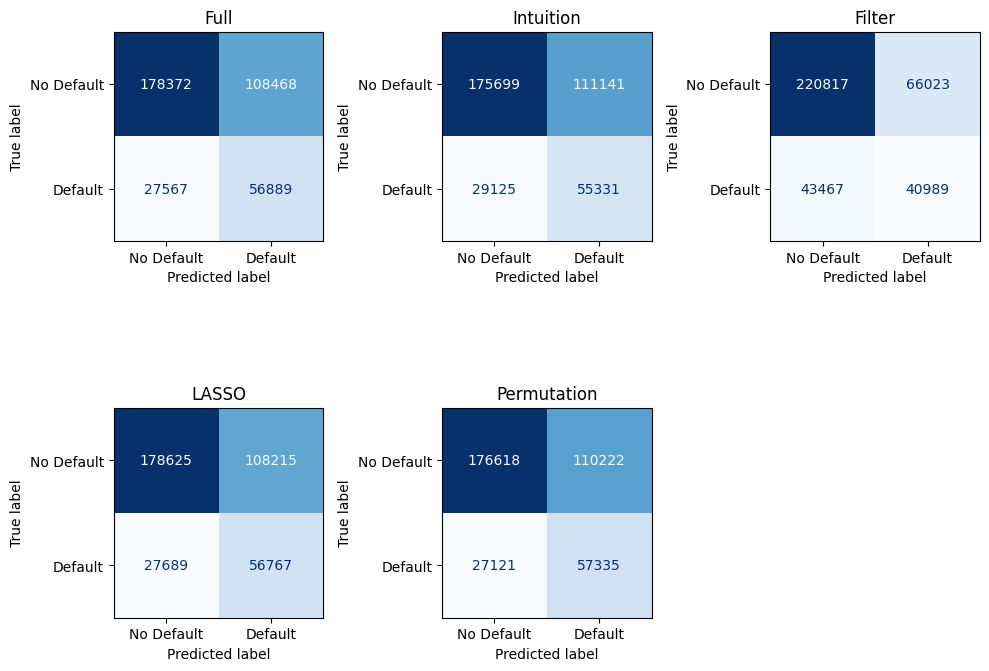

In [53]:
## (b) Confusion Matrix — 3x2 Plot
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

labels = ["No Default", "Default"]

for i, (name, model) in enumerate(models.items()):
    
    X_test_sub = X_test[model.feature_names_in_]
    y_pred_proba = model.predict_proba(X_test_sub)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )
    
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(name)

# Hide last subplot instead of deleting
axes[-1].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()

The confusion matrices confirm the patterns discussed above. 

### 🔷 5.4: Interpretation

#### Which Model Is Best?

**AUC/Gini Comparison**

| Model       | ROC-AUC | Gini  | PR-AUC | F1    | Notes                                      |
|-------------|---------|-------|--------|-------|--------------------------------------------|
| Full        | 0.700   | 0.400 | 0.392  | 0.455 | Benchmark                                  |
| LASSO       | 0.700   | 0.400 | 0.392  | 0.455 | Near-identical to full; drops 2 features   |
| Permutation | 0.700   | 0.400 | 0.391  | 0.455 | Data-driven selection; 69 features         |
| Filter      | 0.695   | 0.389 | 0.384  | 0.428 | Lower recall; misses interaction features  |
| Intuition   | 0.683   | 0.367 | 0.371  | 0.441 | Interpretable, economically grounded       |

The results reveal a clear performance hierarchy. Full, LASSO, and Permutation are 
effectively tied (ROC-AUC ≈ 0.700, within 0.0001 of each other), while Filter trails 
by 0.005 and Intuition by 0.017. The gap at the top is negligible — feature selection 
method does not matter once the full variable set is available. But the intuition model's 
shortfall is real and reflects a deliberate tradeoff.

**Practical Guidance**

- **Best predictive performance:** Full, LASSO, or Permutation — effectively equivalent; 
  LASSO is preferable in practice as it achieves the same AUC with 2 fewer features
- **Interpretability / regulatory use:** Intuition — compact, defensible feature set with 
  clear economic rationale, at a moderate cost of ~1.7 AUC points
- **Research benchmark:** Full model as baseline; LASSO as the parsimonious data-driven 
  specification

#### Why the Top Three Models Are Tied

Once the full variable set is available, logistic regression has exhausted its capacity — 
every additional informative feature contributes additively but marginally. LASSO drops 
only 2 of 81 features, and permutation importance retains 69. Both arrive at essentially 
the same model as the full specification, confirming that the predictive signal is broadly 
distributed and no small subset dominates.

#### Why Intuition Trails

The intuition model deliberately excludes granular credit bureau variables — balance 
measures (`total_bc_limit`, `total_il_high_credit_limit`), utilization details 
(`percent_bc_gt_75`, `bc_util`), and account activity counts (`acc_open_past_24mths`, 
`mo_sin_old_rev_tl_op`) — that collectively account for the performance gap. These 
variables are correlated with the included features but carry independent signal that 
a linear model can exploit. The tradeoff is intentional: the intuition set prioritizes 
interpretability and regulatory defensibility over marginal predictive accuracy.

#### A Note on the Filter Model

The filter model occupies a middle ground — broader than intuition but narrower than the 
data-driven methods — yet underperforms both. This reflects a key limitation of univariate 
F-tests: features are evaluated independently against the target, so variables whose 
predictive value arises from joint relationships (e.g., `dti_x_int_rate`, which interacts 
debt burden with borrowing cost) may be underranked. Permutation importance, evaluated 
within a fitted model, correctly accounts for such dependencies and produces a more 
informative feature ranking.

---
## Section 6: Feature Importance

We examine which features drive model predictions using two complementary approaches:

**(1) Coefficient Table (Signed coefficient, SE, p-value, VIF)**
* Reports the signed logistic regression coefficients for the top 30 features by magnitude, alongside standard errors, Wald p-values, and variance inflation factors.
* Coefficients reflect how strongly each feature affects predicted default risk (in log-odds terms).
* <span style="color:blue">→ how the model internally weights features, with statistical inference</span>

**(2) Permutation Importance**
* We measure feature importance by evaluating how much model performance decreases when each feature is randomly shuffled.
* If shuffling a feature significantly reduces performance, it is important for prediction.
* This method captures the **actual contribution to predictive accuracy**, including interactions and nonlinear effects.
* <span style="color:blue">→ how much features actually matter for prediction</span>

Together, these provide a more complete understanding of feature importance.

### 🔷 6.1: Coefficient table — signed coefficient, SE, p-value, VIF (Top 30)

We report the **signed** logistic regression coefficients alongside their standard errors, p-values (Wald test), and variance inflation factors (VIF) for the 30 features with the largest absolute coefficient in the full model.

- **Coefficient:** log-odds change per one-standard-deviation increase in the feature (after standardization). Positive = higher default risk.
- **Std Error:** asymptotic standard error derived from the Fisher information matrix (inverse of the Hessian of the log-likelihood).
- **p-value:** two-sided Wald test (`z = coef / SE`). Values near 0 indicate the coefficient is statistically distinguishable from zero.
- **VIF:** variance inflation factor for the top-30 feature block. VIF > 10 suggests multicollinearity that may inflate standard errors.

> **Note:** Standard errors are computed analytically from the Fisher information matrix evaluated at the MLE. They are asymptotically valid but do not account for the preprocessing pipeline (imputation, scaling) — treat them as approximate.

In [58]:
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── 1. Reconstruct train+val design matrix ────────────────────────────────────
X_trainval_full = pd.concat([X_train[features_full], X_val[features_full]])

preprocessor_full = logit_full.named_steps["preprocess"]
model_full        = logit_full.named_steps["model"]

X_tr = preprocessor_full.transform(X_trainval_full)
if hasattr(X_tr, "toarray"):
    X_tr = X_tr.toarray()

feature_names_out = preprocessor_full.get_feature_names_out()
coef              = model_full.coef_[0]

# ── 2. Fisher information → SE → Wald p-value ────────────────────────────────
rng = np.random.default_rng(42)
idx = rng.choice(X_tr.shape[0], size=min(300_000, X_tr.shape[0]), replace=False)
Xs  = X_tr[idx]

p_hat = logit_full.predict_proba(X_trainval_full.iloc[idx])[:, 1]
W     = p_hat * (1 - p_hat)

XtWX = (Xs * W[:, None]).T @ Xs
cov  = np.linalg.inv(XtWX)
se       = np.sqrt(np.clip(np.diag(cov), 0, None))
z_scores = coef / np.where(se > 0, se, np.nan)
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))

# ── 3. Build table, select top 30 by |coef| ──────────────────────────────────
coef_df = pd.DataFrame({
    "feature":     feature_names_out,
    "coefficient": coef,
    "std_error":   se,
    "z_score":     z_scores,
    "p_value":     p_values,
    "abs_coef":    np.abs(coef),
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

top30     = coef_df.head(30).copy()
top30_idx = top30.index.tolist()

# ── 4. VIF on the top-30 feature block ───────────────────────────────────────
vif_idx    = rng.choice(Xs.shape[0], size=min(50_000, Xs.shape[0]), replace=False)
X_vif      = Xs[np.ix_(vif_idx, top30_idx)]
vif_values = [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
top30["VIF"] = vif_values

# ── 5. Display ────────────────────────────────────────────────────────────────
display_df = top30[["feature", "coefficient", "std_error", "z_score", "p_value", "VIF"]].copy()
display_df.columns = ["Feature", "Coefficient", "Std Error", "z-score", "p-value", "VIF"]

display_df["Coefficient"] = display_df["Coefficient"].map("{:+.4f}".format)
display_df["Std Error"]   = display_df["Std Error"].map("{:.4f}".format)
display_df["z-score"]     = display_df["z-score"].map("{:+.2f}".format)
display_df["p-value"]     = display_df["p-value"].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")
display_df["VIF"]         = display_df["VIF"].map("{:.1f}".format)

display(display_df.reset_index(drop=True))

,Feature,Coefficient,Std Error,z-score,p-value,VIF
0,num__term,+0.6843,0.0158,+43.28,0.00e+00,39.7
1,cat__fico_band_800_plus,-0.4888,0.0964,-5.07,4.00e-07,3.7
2,cat__purpose_small_business,+0.4328,0.0647,+6.69,2.22e-11,33.3
3,cat__home_ownership_MORTGAGE,-0.3825,0.0536,-7.13,9.69e-13,1.0
4,cat__fico_band_740_799,-0.3760,0.0298,-12.62,0.00e+00,1.6
5,num__loan_to_installment,-0.3114,0.0190,-16.36,0.00e+00,1.4
6,cat__home_ownership_OWN,-0.2613,0.0549,-4.76,1.97e-06,1.2
7,cat__application_type_Joint App,-0.2578,0.0424,-6.08,1.24e-09,1.3
8,num__installment,+0.2544,0.0348,+7.30,2.89e-13,2.6
9,cat__dti_band_very_low,-0.2223,0.0265,-8.39,0.00e+00,1.0


The top coefficients organize into four interpretable groups.

1. **Loan structure** dominates the ranking. `term` has the largest effect (+0.68) and the
highest VIF (39.7), reflecting collinearity with `installment` (+0.25) and
`loan_to_installment` (-0.31) — interpret these jointly as a repayment burden cluster
rather than individually.

2. **Credit quality bands** follow clean monotonic gradients. Higher FICO bands reduce default
risk progressively (800+: -0.49, 740–799: -0.38, 670–739: -0.12), as do lower DTI bands
(very_low: -0.22, low: -0.19, medium: -0.10). Both sets are highly significant with low
VIF, making them the most reliable individual signals in the model.

3. **Borrower characteristics** matter in expected directions. Home ownership reduces risk in
order of financial stability (MORTGAGE: -0.38, OWN: -0.26, RENT: -0.15), and joint
applications lower risk (-0.26), likely reflecting dual-income underwriting. Small business
loans stand out as the riskiest purpose (+0.43); credit card consolidation is modestly
protective (-0.16). Wedding, house, and moving purposes are not statistically significant.

4. **Credit capacity and activity** show opposing effects. Higher approved credit limits
(`total_bc_limit`, `total_il_high_credit_limit`) reduce risk — better-quality borrowers
receive higher limits — while recent account openings (`acc_open_past_24mths`: +0.17) and
higher `dti_x_int_rate` (+0.11) increase it, capturing financial stress at origination.

Overall, VIF values are low across most features (median ≈ 2), and nearly all coefficients
are highly significant (p < 0.01). The three exceptions — `purpose_wedding`,
`purpose_house`, and `purpose_moving` — do not reach conventional significance thresholds.

### 🔷 6.2: Permutation importance on test set

Permutation importance highlights the features that contribute most to predictive
performance. The top drivers are dominated by loan structure variables (`term`,
`installment`, `loan_to_installment`), confirming that repayment terms are the single
most informative dimension for default prediction. Credit capacity variables
(`total_il_high_credit_limit`, `total_bc_limit`) rank next, reflecting that approved
limits are a strong proxy for borrower quality.

Borrower profile variables — `home_ownership`, `income_to_loan_ratio`, and account
breadth measures (`open_acc`, `total_acc`, `avg_cur_bal`) — contribute meaningfully
but to a lesser extent. Engineered features capturing repayment stress (`dti_x_int_rate`)
and credit history (`credit_age`, `mo_sin_old_rev_tl_op`) also appear in the top tier.
Banded risk indicators (`fico_band`, `dti_band`) and loan purpose contribute modestly,
suggesting their signal is partially absorbed by correlated variables elsewhere in the
model.

Overall, importance values are relatively small and decline gradually, indicating that
predictive power is spread across many features rather than concentrated in a few dominant
variables — consistent with the model's moderate discriminatory performance.

In [61]:
perm_full_result = permutation_importance(
    logit_full,
    X_test[features_full],
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance_full = pd.DataFrame({
    "feature": features_full,
    "importance": perm_full_result.importances_mean,
    "importance_std": perm_full_result.importances_std
}).sort_values("importance", ascending=False)

display(perm_importance_full.head(20))

,feature,importance,importance_std
1,term,0.106047,0.001043
2,installment,0.034831,0.000312
75,loan_to_installment,0.026283,0.000449
69,total_il_high_credit_limit,0.014431,0.000222
68,total_bc_limit,0.012100,0.000196
11,open_acc,0.009058,0.000117
70,credit_age,0.006839,0.000134
4,home_ownership,0.005828,0.000167
71,income_to_loan_ratio,0.005643,0.000283
74,dti_x_int_rate,0.005120,0.000098


---
## Section 7: Discussions

#### How to Improve Prediction Performance

The current results (e.g., confusion matrices and recall) suggest that the model still misses a meaningful number of default cases. Below are several directions to improve predictive performance:

- **Tune the decision threshold**  
  Select a threshold based on the relative cost of false negatives (missing defaults) and false positives, rather than using a fixed value.

- **Address class imbalance**  
  Use class weights or resampling techniques to better capture the minority class (defaults).

- **Improve feature engineering**  
  Construct additional features such as ratios, interactions (e.g., `dti × int_rate`), or binned variables to better capture nonlinear relationships.

- **Incorporate macroeconomic or local features**  
  Add external variables such as local unemployment rates or state-level economic indicators. These can capture broader economic conditions that affect repayment ability. It is important to align these variables with the loan origination date to avoid using future information.

- **Try more flexible models**  
  Tree-based methods (e.g., Random Forest, XGBoost, LightGBM) can automatically capture nonlinearities and interactions and may improve performance.

Overall, improving performance will likely require a combination of better features, appropriate threshold selection, and more flexible modeling approaches.